In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shahpranshu27/rossman-store-sales")

print("Path to dataset files:", path)

Path to dataset files: /home/kimo/.cache/kagglehub/datasets/shahpranshu27/rossman-store-sales/versions/1



Loading datasets...


/tmp/ipykernel_158267/379392092.py:14: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('rossmann_data/train.csv', parse_dates=['Date'])



TRAIN DATASET
Shape: (1017209, 9)

Columns: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']

First few rows:
   Store  DayOfWeek       Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5 2015-07-31   5263        555     1      1            0   
1      2          5 2015-07-31   6064        625     1      1            0   
2      3          5 2015-07-31   8314        821     1      1            0   
3      4          5 2015-07-31  13995       1498     1      1            0   
4      5          5 2015-07-31   4822        559     1      1            0   

   SchoolHoliday  
0              1  
1              1  
2              1  
3              1  
4              1  

Data types:
Store                     int64
DayOfWeek                 int64
Date             datetime64[ns]
Sales                     int64
Customers                 int64
Open                      int64
Promo                     int64
StateHoliday   

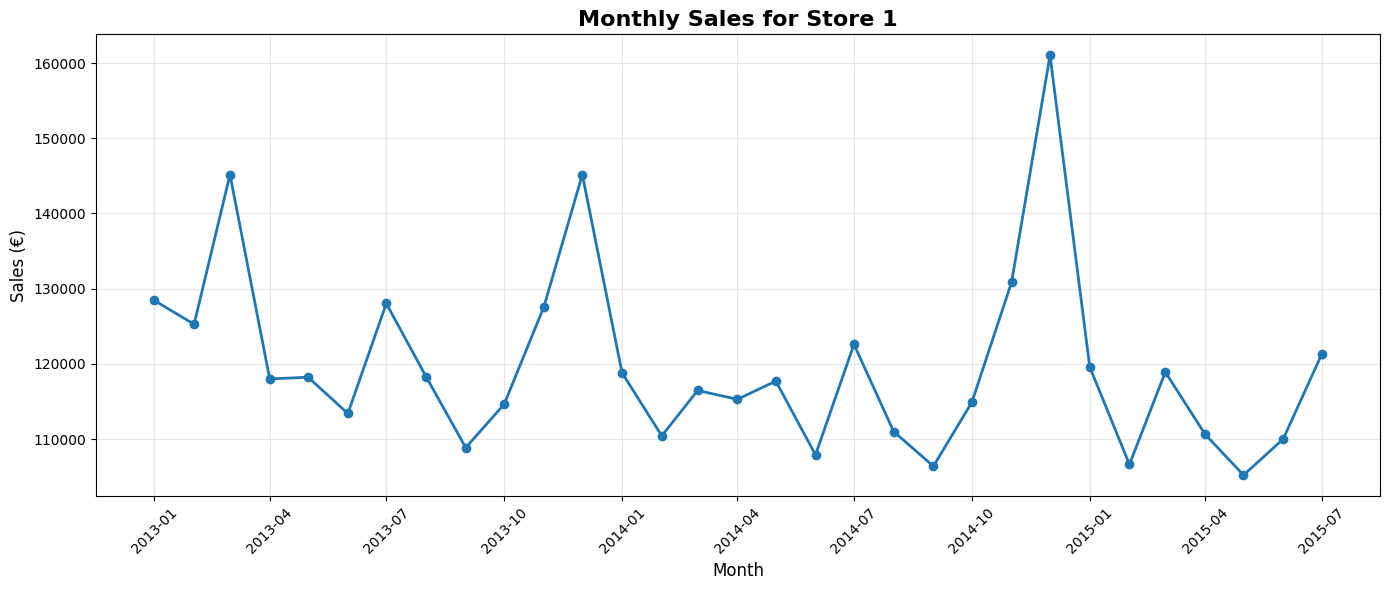


Monthly Sales Statistics:
count     33485.000000
mean     175397.360699
std       65194.001011
min           0.000000
25%      132416.000000
50%      164757.000000
75%      203785.000000
max      756285.000000
Name: Sales, dtype: float64

DATA READY FOR MODELING!
You now have 33485 monthly records across 1115 stores
Next steps: Feature engineering and model training


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile


# ============================================
# STEP 3: Load the Data
# ============================================
print("\nLoading datasets...")

train = pd.read_csv('rossmann_data/train.csv', parse_dates=['Date'])
test = pd.read_csv('rossmann_data/test.csv', parse_dates=['Date'])
store = pd.read_csv('rossmann_data/store.csv')

# Display basic information
print("\n" + "="*60)
print("TRAIN DATASET")
print("="*60)
print("Shape:", train.shape)
print("\nColumns:", train.columns.tolist())
print("\nFirst few rows:")
print(train.head())
print("\nData types:")
print(train.dtypes)

print("\n" + "="*60)
print("STORE INFORMATION")
print("="*60)
print("Shape:", store.shape)
print("\nColumns:", store.columns.tolist())
print("\nFirst few rows:")
print(store.head())

# Check for missing values
print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
print("Missing values in train:")
print(train.isnull().sum())
print("\nMissing values in store:")
print(store.isnull().sum())

# ============================================
# STEP 4: Merge and Prepare Data
# ============================================
print("\n" + "="*60)
print("MERGING DATASETS")
print("="*60)

# Merge train with store information
train_full = train.merge(store, on='Store', how='left')
print("Merged dataset shape:", train_full.shape)
print("Merged columns:", train_full.columns.tolist())

# Basic statistics
print("\n" + "="*60)
print("SALES STATISTICS")
print("="*60)
print(train['Sales'].describe())

# Display date range
print("\n" + "="*60)
print("DATE RANGE")
print("="*60)
print(f"From: {train['Date'].min()}")
print(f"To: {train['Date'].max()}")
print(f"Total days: {(train['Date'].max() - train['Date'].min()).days}")

# ============================================
# STEP 5: Aggregate to Monthly Data
# ============================================
print("\n" + "="*60)
print("AGGREGATING TO MONTHLY DATA")
print("="*60)

# Add date components
train_full['Year'] = train_full['Date'].dt.year
train_full['Month'] = train_full['Date'].dt.month
train_full['YearMonth'] = train_full['Date'].dt.to_period('M')

# Monthly aggregation per store
monthly_sales = train_full.groupby(['Store', 'YearMonth']).agg({
    'Sales': 'sum',           # Total monthly sales (TARGET)
    'Customers': 'sum',        # Total monthly customers
    'Promo': 'sum',           # Number of promo days
    'Open': 'sum',            # Number of open days
    'SchoolHoliday': 'sum'    # Number of school holiday days
}).reset_index()

# Add store information to monthly data
monthly_sales = monthly_sales.merge(store, on='Store', how='left')

# Convert period back to timestamp
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].dt.to_timestamp()

print("\nMonthly aggregated data:")
print(monthly_sales.head(10))
print(f"\nShape: {monthly_sales.shape}")
print(f"Number of stores: {monthly_sales['Store'].nunique()}")
print(f"Number of months: {monthly_sales['YearMonth'].nunique()}")

# ============================================
# STEP 6: Visualize Sample Store
# ============================================
print("\n" + "="*60)
print("VISUALIZATION")
print("="*60)

# Visualize monthly sales for a sample store
sample_store = monthly_sales[monthly_sales['Store'] == 1]

plt.figure(figsize=(14, 6))
plt.plot(sample_store['YearMonth'], sample_store['Sales'], marker='o', linewidth=2, markersize=6)
plt.title('Monthly Sales for Store 1', fontsize=16, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Sales (€)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('rossmann_data/monthly_sales_store1.png', dpi=300)
print("Plot saved as 'rossmann_data/monthly_sales_store1.png'")
plt.show()

# Summary statistics for monthly data
print("\nMonthly Sales Statistics:")
print(monthly_sales['Sales'].describe())

print("\n" + "="*60)
print("DATA READY FOR MODELING!")
print("="*60)
print(f"You now have {len(monthly_sales)} monthly records across {monthly_sales['Store'].nunique()} stores")
print("Next steps: Feature engineering and model training")

In [ ]:
import joblib

# 1. Save the trained XGBoost model
joblib.dump(best_model, "retail_price_xgboost_model.pkl")

# 2. Save feature column names (critical for consistent input)
joblib.dump(feature_cols, "model_feature_columns.pkl")

# 3. Save label encoders for categorical variables
joblib.dump(label_encoders, "categorical_label_encoders.pkl")

# 4. (Optional) Save metadata like forecast date or data version
model_metadata = {
    'target_column': 'VALUE',
    'forecast_date': forecast_date if 'forecast_date' in locals() else None,
    'training_data_shape': modeling_df.shape,
    'feature_count': len(feature_cols),
    'model_type': 'XGBoostRegressor (tuned)'
}
joblib.dump(model_metadata, "model_metadata.pkl")

print("✅ Model and supporting files saved successfully!")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import warnings
import pickle
import os
from datetime import timedelta

warnings.filterwarnings('ignore')

# ============================================
# CONFIGURATION
# ============================================
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Context windows to try (days of historical data to use)
CONTEXT_WINDOWS = [7, 14, 30, 60, 90]

# Forecast horizons
HORIZONS = {
    'day': 1,      # 1 day ahead
    'week': 7,     # 7 days ahead (sum)
    'month': 30    # 30 days ahead (sum)
}

# ============================================
# STEP 1: Load and Prepare Data
# ============================================
print("\n" + "="*80)
print("LOADING DATA")
print("="*80)

train = pd.read_csv('/content/rossmann_data/train.csv', parse_dates=['Date'])
store = pd.read_csv('/content/rossmann_data/store.csv')

# Merge with store info
train_full = train.merge(store, on='Store', how='left')
print(f"Loaded {len(train_full)} records from {train_full['Store'].nunique()} stores")
print(f"Date range: {train_full['Date'].min()} to {train_full['Date'].max()}")

# ============================================
# STEP 2: Data Cleaning and Preprocessing
# ============================================
print("\n" + "="*80)
print("PREPROCESSING")
print("="*80)

# Fill missing values
train_full['CompetitionDistance'].fillna(train_full['CompetitionDistance'].median(), inplace=True)
train_full['CompetitionOpenSinceMonth'].fillna(0, inplace=True)
train_full['CompetitionOpenSinceYear'].fillna(0, inplace=True)
train_full['Promo2SinceWeek'].fillna(0, inplace=True)
train_full['Promo2SinceYear'].fillna(0, inplace=True)
train_full['PromoInterval'].fillna('None', inplace=True)

# Encode categorical variables
le_store_type = LabelEncoder()
le_assortment = LabelEncoder()

train_full['StoreType_enc'] = le_store_type.fit_transform(train_full['StoreType'])
train_full['Assortment_enc'] = le_assortment.fit_transform(train_full['Assortment'])

# Extract date features
train_full['Year'] = train_full['Date'].dt.year
train_full['Month'] = train_full['Date'].dt.month
train_full['Day'] = train_full['Date'].dt.day
train_full['DayOfWeek_num'] = train_full['Date'].dt.dayofweek
train_full['WeekOfYear'] = train_full['Date'].dt.isocalendar().week
train_full['Quarter'] = train_full['Date'].dt.quarter

# Sort by store and date
train_full = train_full.sort_values(['Store', 'Date']).reset_index(drop=True)

print("Preprocessing complete!")

# ============================================
# STEP 3: Feature Engineering Function
# ============================================
def create_features(df, context_window, target='Sales'):
    """
    Create features with rolling statistics based on context window
    """
    df = df.copy()
    
    # Ensure sorted by Store and Date
    df = df.sort_values(['Store', 'Date']).reset_index(drop=True)
    
    # Rolling features (lag features)
    for lag in [1, 2, 3, 7, 14, 30]:
        if lag <= context_window:
            df[f'{target}_lag_{lag}'] = df.groupby('Store')[target].shift(lag)
    
    # Rolling statistics
    for window in [7, 14, 30]:
        if window <= context_window:
            df[f'{target}_rolling_mean_{window}'] = df.groupby('Store')[target].transform(
                lambda x: x.rolling(window=window, min_periods=1).mean().shift(1)
            )
            df[f'{target}_rolling_std_{window}'] = df.groupby('Store')[target].transform(
                lambda x: x.rolling(window=window, min_periods=1).std().shift(1)
            )
            df[f'{target}_rolling_max_{window}'] = df.groupby('Store')[target].transform(
                lambda x: x.rolling(window=window, min_periods=1).max().shift(1)
            )
            df[f'{target}_rolling_min_{window}'] = df.groupby('Store')[target].transform(
                lambda x: x.rolling(window=window, min_periods=1).min().shift(1)
            )
    
    # Exponential moving average
    df[f'{target}_ema_7'] = df.groupby('Store')[target].transform(
        lambda x: x.ewm(span=7, adjust=False).mean().shift(1)
    )
    
    return df

# ============================================
# STEP 4: Create Targets for Different Horizons
# ============================================
def create_targets(df, horizon_days, target='Sales'):
    """
    Create target variable for different forecast horizons
    - For 1 day: next day value
    - For 7 days: sum of next 7 days
    - For 30 days: sum of next 30 days
    """
    df = df.copy()
    
    if horizon_days == 1:
        # Next day prediction
        df[f'{target}_target'] = df.groupby('Store')[target].shift(-1)
    else:
        # Sum of next N days
        df[f'{target}_target'] = df.groupby('Store')[target].transform(
            lambda x: x.rolling(window=horizon_days, min_periods=horizon_days).sum().shift(-horizon_days+1)
        )
    
    return df

# ============================================
# STEP 5: Train Model Function
# ============================================
def train_model(X_train, y_train, X_val, y_val, model_name='xgboost'):
    """
    Train a model and return it with validation metrics
    """
    if model_name == 'xgboost':
        model = xgb.XGBRegressor(
            n_estimators=500,
            max_depth=7,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    elif model_name == 'gradient_boosting':
        model = GradientBoostingRegressor(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            random_state=RANDOM_STATE
        )
    else:  # random_forest
        model = RandomForestRegressor(
            n_estimators=200,
            max_depth=15,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    
    # Train
    model.fit(X_train, y_train)
    
    # Validate
    y_pred = model.predict(X_val)
    
    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)
    mape = np.mean(np.abs((y_val - y_pred) / (y_val + 1))) * 100
    
    return model, {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

# ============================================
# STEP 6: Main Training Loop
# ============================================
print("\n" + "="*80)
print("TRAINING 6 INDEPENDENT MODELS")
print("="*80)

# Base features
base_features = [
    'Store', 'DayOfWeek', 'Open', 'Promo', 'SchoolHoliday',
    'StoreType_enc', 'Assortment_enc', 'CompetitionDistance',
    'Promo2', 'Year', 'Month', 'Day', 'DayOfWeek_num', 
    'WeekOfYear', 'Quarter'
]

# Store all results
results = {}
models_dict = {}

# Train 6 models: 2 targets (Sales, Customers) x 3 horizons (day, week, month)
for target in ['Sales', 'Customers']:
    for horizon_name, horizon_days in HORIZONS.items():
        
        print(f"\n{'='*80}")
        print(f"TRAINING MODEL: {target} - {horizon_name.upper()} ({horizon_days} days)")
        print(f"{'='*80}")
        
        best_model = None
        best_metrics = None
        best_context = None
        best_features = None
        
        # Try different context windows
        for context_window in CONTEXT_WINDOWS:
            print(f"\n  Testing context window: {context_window} days")
            
            # Create features and targets
            df_features = create_features(train_full, context_window, target=target)
            df_with_target = create_targets(df_features, horizon_days, target=target)
            
            # Drop rows with NaN in target or features
            df_model = df_with_target.dropna()
            
            if len(df_model) < 1000:
                print(f"    Skipping - insufficient data after dropna: {len(df_model)} rows")
                continue
            
            # Get feature columns
            feature_cols = base_features.copy()
            for col in df_model.columns:
                if (col.startswith(f'{target}_lag_') or 
                    col.startswith(f'{target}_rolling_') or 
                    col.startswith(f'{target}_ema_')):
                    feature_cols.append(col)
            
            # Prepare data
            X = df_model[feature_cols].copy()
            y = df_model[f'{target}_target'].copy()
            
            # Filter out stores with closed days for target (Open=0)
            if target == 'Sales':
                valid_indices = df_model['Open'] == 1
                X = X[valid_indices]
                y = y[valid_indices]
            
            # Time-based split (last 20% for validation)
            split_idx = int(len(X) * 0.8)
            X_train, X_val = X[:split_idx], X[split_idx:]
            y_train, y_val = y[:split_idx], y[split_idx:]
            
            print(f"    Train samples: {len(X_train)}, Val samples: {len(X_val)}")
            
            # Scale features
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            
            # Train model
            model, metrics = train_model(
                X_train_scaled, y_train, 
                X_val_scaled, y_val, 
                model_name='xgboost'
            )
            
            print(f"    Results - MAE: {metrics['MAE']:.2f}, RMSE: {metrics['RMSE']:.2f}, " +
                  f"R2: {metrics['R2']:.4f}, MAPE: {metrics['MAPE']:.2f}%")
            
            # Keep best model based on MAE
            if best_model is None or metrics['MAE'] < best_metrics['MAE']:
                best_model = model
                best_metrics = metrics
                best_context = context_window
                best_features = feature_cols
                best_scaler = scaler
        
        # Store best model and results
        model_key = f"{target}_{horizon_name}"
        models_dict[model_key] = {
            'model': best_model,
            'scaler': best_scaler,
            'features': best_features,
            'context_window': best_context,
            'metrics': best_metrics
        }
        
        results[model_key] = {
            'Target': target,
            'Horizon': horizon_name,
            'Horizon_Days': horizon_days,
            'Best_Context_Window': best_context,
            'MAE': best_metrics['MAE'],
            'RMSE': best_metrics['RMSE'],
            'R2': best_metrics['R2'],
            'MAPE': best_metrics['MAPE']
        }
        
        print(f"\n  ✓ BEST MODEL - Context: {best_context} days")
        print(f"    MAE: {best_metrics['MAE']:.2f}")
        print(f"    RMSE: {best_metrics['RMSE']:.2f}")
        print(f"    R2: {best_metrics['R2']:.4f}")
        print(f"    MAPE: {best_metrics['MAPE']:.2f}%")

# ============================================
# STEP 7: Summary Results
# ============================================
print("\n" + "="*80)
print("TRAINING SUMMARY")
print("="*80)

results_df = pd.DataFrame(results).T
print(results_df.to_string())

# ============================================
# STEP 8: Save Models
# ============================================
print("\n" + "="*80)
print("SAVING MODELS")
print("="*80)

os.makedirs('rossmann_models', exist_ok=True)

for model_key, model_data in models_dict.items():
    filename = f"rossmann_models/{model_key}_model.pkl"
    with open(filename, 'wb') as f:
        pickle.dump(model_data, f)
    print(f"✓ Saved: {filename}")

# Save results summary
results_df.to_csv('rossmann_models/training_results.csv')
print("\n✓ Saved: rossmann_models/training_results.csv")

# Save label encoders
with open('rossmann_models/label_encoders.pkl', 'wb') as f:
    pickle.dump({
        'StoreType': le_store_type,
        'Assortment': le_assortment
    }, f)
print("✓ Saved: rossmann_models/label_encoders.pkl")

# ============================================
# STEP 9: Visualization
# ============================================
print("\n" + "="*80)
print("CREATING VISUALIZATIONS")
print("="*80)

# Plot 1: Model Performance Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# MAE by model
ax1 = axes[0, 0]
mae_data = results_df.groupby('Target')['MAE'].apply(list)
x = np.arange(len(HORIZONS))
width = 0.35
ax1.bar(x - width/2, [results_df[(results_df['Target'] == 'Sales')].iloc[i]['MAE'] 
                       for i in range(3)], width, label='Sales', alpha=0.8)
ax1.bar(x + width/2, [results_df[(results_df['Target'] == 'Customers')].iloc[i]['MAE'] 
                       for i in range(3)], width, label='Customers', alpha=0.8)
ax1.set_xlabel('Forecast Horizon', fontsize=11)
ax1.set_ylabel('MAE', fontsize=11)
ax1.set_title('Mean Absolute Error by Horizon', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(['Day', 'Week', 'Month'])
ax1.legend()
ax1.grid(True, alpha=0.3)

# R2 Score
ax2 = axes[0, 1]
ax2.bar(x - width/2, [results_df[(results_df['Target'] == 'Sales')].iloc[i]['R2'] 
                       for i in range(3)], width, label='Sales', alpha=0.8)
ax2.bar(x + width/2, [results_df[(results_df['Target'] == 'Customers')].iloc[i]['R2'] 
                       for i in range(3)], width, label='Customers', alpha=0.8)
ax2.set_xlabel('Forecast Horizon', fontsize=11)
ax2.set_ylabel('R² Score', fontsize=11)
ax2.set_title('R² Score by Horizon', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(['Day', 'Week', 'Month'])
ax2.legend()
ax2.grid(True, alpha=0.3)

# MAPE
ax3 = axes[1, 0]
ax3.bar(x - width/2, [results_df[(results_df['Target'] == 'Sales')].iloc[i]['MAPE'] 
                       for i in range(3)], width, label='Sales', alpha=0.8)
ax3.bar(x + width/2, [results_df[(results_df['Target'] == 'Customers')].iloc[i]['MAPE'] 
                       for i in range(3)], width, label='Customers', alpha=0.8)
ax3.set_xlabel('Forecast Horizon', fontsize=11)
ax3.set_ylabel('MAPE (%)', fontsize=11)
ax3.set_title('Mean Absolute Percentage Error by Horizon', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(['Day', 'Week', 'Month'])
ax3.legend()
ax3.grid(True, alpha=0.3)

# Best Context Window
ax4 = axes[1, 1]
context_sales = [results_df[(results_df['Target'] == 'Sales')].iloc[i]['Best_Context_Window'] 
                 for i in range(3)]
context_customers = [results_df[(results_df['Target'] == 'Customers')].iloc[i]['Best_Context_Window'] 
                     for i in range(3)]
ax4.bar(x - width/2, context_sales, width, label='Sales', alpha=0.8)
ax4.bar(x + width/2, context_customers, width, label='Customers', alpha=0.8)
ax4.set_xlabel('Forecast Horizon', fontsize=11)
ax4.set_ylabel('Context Window (days)', fontsize=11)
ax4.set_title('Best Context Window by Horizon', fontsize=13, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(['Day', 'Week', 'Month'])
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rossmann_models/model_performance.png', dpi=300, bbox_inches='tight')
print("✓ Saved: rossmann_models/model_performance.png")
plt.close()

# ============================================
# STEP 10: Feature Importance (for one model as example)
# ============================================
print("\nExtracting feature importance...")

# Get Sales-Day model as example
model_data = models_dict['Sales_day']
model = model_data['model']
features = model_data['features']

# Get feature importance
if hasattr(model, 'feature_importances_'):
    importance = model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': features,
        'Importance': importance
    }).sort_values('Importance', ascending=False).head(20)
    
    plt.figure(figsize=(12, 8))
    plt.barh(range(len(feature_importance_df)), feature_importance_df['Importance'], alpha=0.8)
    plt.yticks(range(len(feature_importance_df)), feature_importance_df['Feature'])
    plt.xlabel('Importance', fontsize=11)
    plt.ylabel('Feature', fontsize=11)
    plt.title('Top 20 Features - Sales Day Model', fontsize=13, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('rossmann_models/feature_importance.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: rossmann_models/feature_importance.png")
    plt.close()

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "="*80)
print("TRAINING COMPLETE!")
print("="*80)
print("\n📊 Trained Models:")
print("   1. Sales - Day (1 day ahead)")
print("   2. Sales - Week (7 days sum)")
print("   3. Sales - Month (30 days sum)")
print("   4. Customers - Day (1 day ahead)")
print("   5. Customers - Week (7 days sum)")
print("   6. Customers - Month (30 days sum)")
print("\n📁 Output Files:")
print("   - rossmann_models/*.pkl (6 model files + encoders)")
print("   - rossmann_models/training_results.csv")
print("   - rossmann_models/model_performance.png")
print("   - rossmann_models/feature_importance.png")
print("\n🎯 Next Steps:")
print("   - Use these models to make predictions on new data")
print("   - Models are optimized with best context windows")
print("   - Each model is independent and ready for deployment")
print("="*80)